In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [3]:
# Load the CICIDS 2017 dataset (replace with your dataset path)
df = pd.read_csv('cicids2017_cleaned.csv')

# Display the first few rows of the dataset
df.head()

# Drop non-feature columns like 'Timestamp', 'Flow ID' if present
#df = df.drop(columns=['Timestamp', 'Flow ID'], axis=1)

# If there are any categorical columns (like 'Label'), encode them
label_encoder = LabelEncoder()
df['Attack Type'] = label_encoder.fit_transform(df['Attack Type'])

# Split features and labels
X = df.drop('Attack Type', axis=1).values
y = df['Attack Type'].values

# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert labels to one-hot encoding for multiclass classification
y_onehot = to_categorical(y)

# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_onehot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Check the shapes of the splits
print(X_train.shape, X_val.shape, X_test.shape)


(1764525, 52) (378113, 52) (378113, 52)


In [4]:
model = Sequential()

# Reshaping the data for RNN [samples, timesteps, features]
# For simplicity, we treat the data as a sequence of length 1
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Adding an RNN layer
model.add(SimpleRNN(64, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), return_sequences=False))

# Dropout for regularization
model.add(Dropout(0.5))

# Output layer with softmax for multiclass classification
model.add(Dense(y_onehot.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,943 (31.03 KB)

 Trainable params: 7,943 (31.03 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train_rnn, y_train, epochs=10, batch_size=32, validation_data=(X_val_rnn, y_val))


Epoch 1/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - accuracy: 0.9576 - loss: 0.1336 - val_accuracy: 0.9774 - val_loss: 0.0584
Epoch 2/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step - accuracy: 0.9729 - loss: 0.0732 - val_accuracy: 0.9763 - val_loss: 0.0547
Epoch 3/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step - accuracy: 0.9742 - loss: 0.0724 - val_accuracy: 0.9782 - val_loss: 0.0541
Epoch 4/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step - accuracy: 0.9754 - loss: 0.0760 - val_accuracy: 0.9798 - val_loss: 0.0499
Epoch 5/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - accuracy: 0.9763 - loss: 0.0657 - val_accuracy: 0.9829 - val_loss: 0.0476
Epoch 6/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step - accuracy: 0.9771 - loss: 0.0625 - val_accuracy: 0.9786 - val_loss: 0.0488
Epoch 7/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - accuracy: 0.9775 - loss: 0.0622 - val_accuracy: 0.9831 - val_loss: 0.0458
Epoch 8/10
55142/55142 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step - accuracy: 

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 7s 587us/step
Accuracy: 0.9826189525353531
Confusion Matrix:
[[     4      0      0      0    289      0      0]
 [     0   1032      0      0    336      0      0]
 [     0      0  19350     10     29      0      0]
 [     0      0      0  27766   1319      0      0]
 [     0      0     33    646 311564   1686      0]
 [     0      0      0      0   1898  11816      0]
 [     0      0      0      0    326      0      9]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.03       293
           1       1.00      0.75      0.86      1368
           2       1.00      1.00      1.00     19389
           3       0.98      0.95      0.97     29085
           4       0.99      0.99      0.99    313929
           5       0.88      0.86      0.87     13714
           6       1.00      0.03      0.05       335

    accuracy                           0.98    378113
   macro avg       0.98      0

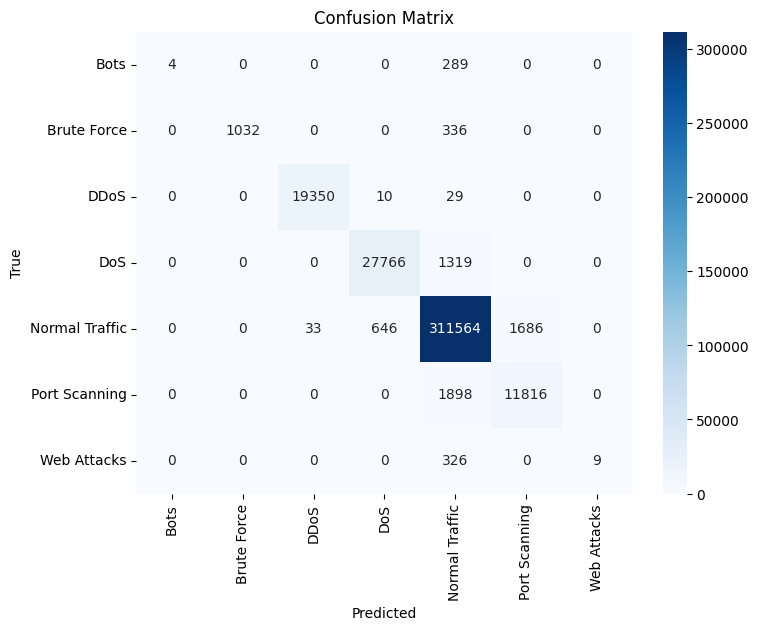

In [6]:
y_pred_prob = model.predict(X_test_rnn)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert y_test back from one-hot encoding to labels
y_test_labels = np.argmax(y_test, axis=1)

# Compute accuracy
accuracy = accuracy_score(y_test_labels, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


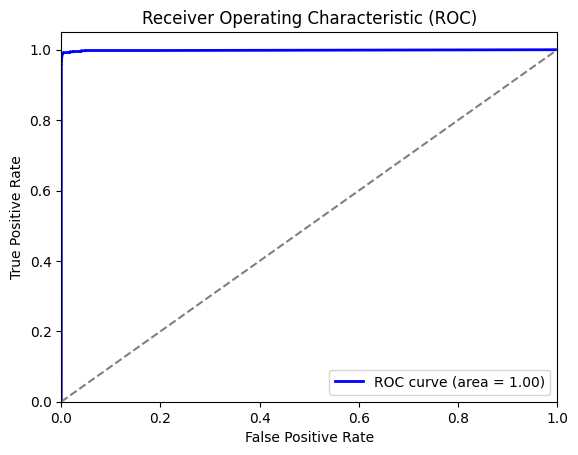

In [7]:
fpr, tpr, _ = roc_curve(y_test_labels, y_pred_prob[:, 1], pos_label=1)  # Assuming class 1 is the positive class
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


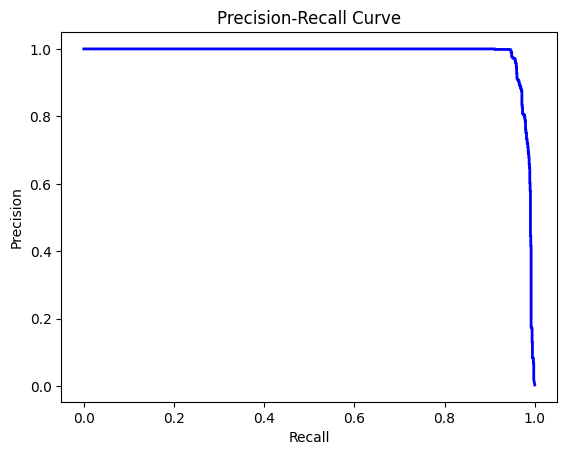

In [8]:
precision, recall, _ = precision_recall_curve(y_test_labels, y_pred_prob[:, 1], pos_label=1)

plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()
